In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
# read list of dictionaries line by line and convert to pandas dataframe
def read_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            data.append(eval(line))
    return pd.DataFrame(data)
df = read_jsonl('simulation_results.txt')

In [41]:
df.head()

,Spearman_correlation,Importance_MSE,precision,recall,f1_score,mcc,accuracy,true_positives,false_positives,true_negatives,...,Avg_group_variance,Avg_group_sum_error,n_features,sample_size,n_informative_groups,features_per_group,random_state,approach,r_squared,model
0,0.959318,0.001984,0.833333,1.0,0.909091,0.910527,0.995,5,1,194,...,0.0,0.155765,200,1000,10,1,0,deepbreaks,0.540144,gbc
1,0.924359,0.006058,0.070423,1.0,0.131579,0.215841,0.670,5,66,129,...,0.0,0.084921,200,1000,10,1,0,pyseer,0.520000,lasso
2,0.956413,0.002575,0.800000,0.8,0.800000,0.794872,0.990,4,1,194,...,0.0,0.121372,200,1000,10,1,1,deepbreaks,0.491406,gbc
3,0.936680,0.004101,0.068493,1.0,0.128205,0.211207,0.660,5,68,127,...,0.0,0.198137,200,1000,10,1,1,pyseer,0.562000,lasso
4,0.954893,0.001794,0.555556,1.0,0.714286,0.737672,0.980,5,4,191,...,0.0,0.150076,200,1000,10,1,2,deepbreaks,0.500279,gbc_2


In [93]:
# melt the dataframe to long format
df.rename(columns={'Spearman_correlation': 'Correlation',
                   'precision': 'Precision',
                     'recall': 'Recall',
                        'f1_score': 'F1_score',
                        'mcc': 'MCC',
                        'accuracy': 'Accuracy'}, inplace=True)
df_melted = df.melt(id_vars=['approach', 'features_per_group'],
                     value_vars=['Correlation', 'Precision', 'Recall', 'F1_score', 'MCC', 'Accuracy'],
                     var_name='metric',
                     value_name='value')


<Figure size 720x400 with 0 Axes>

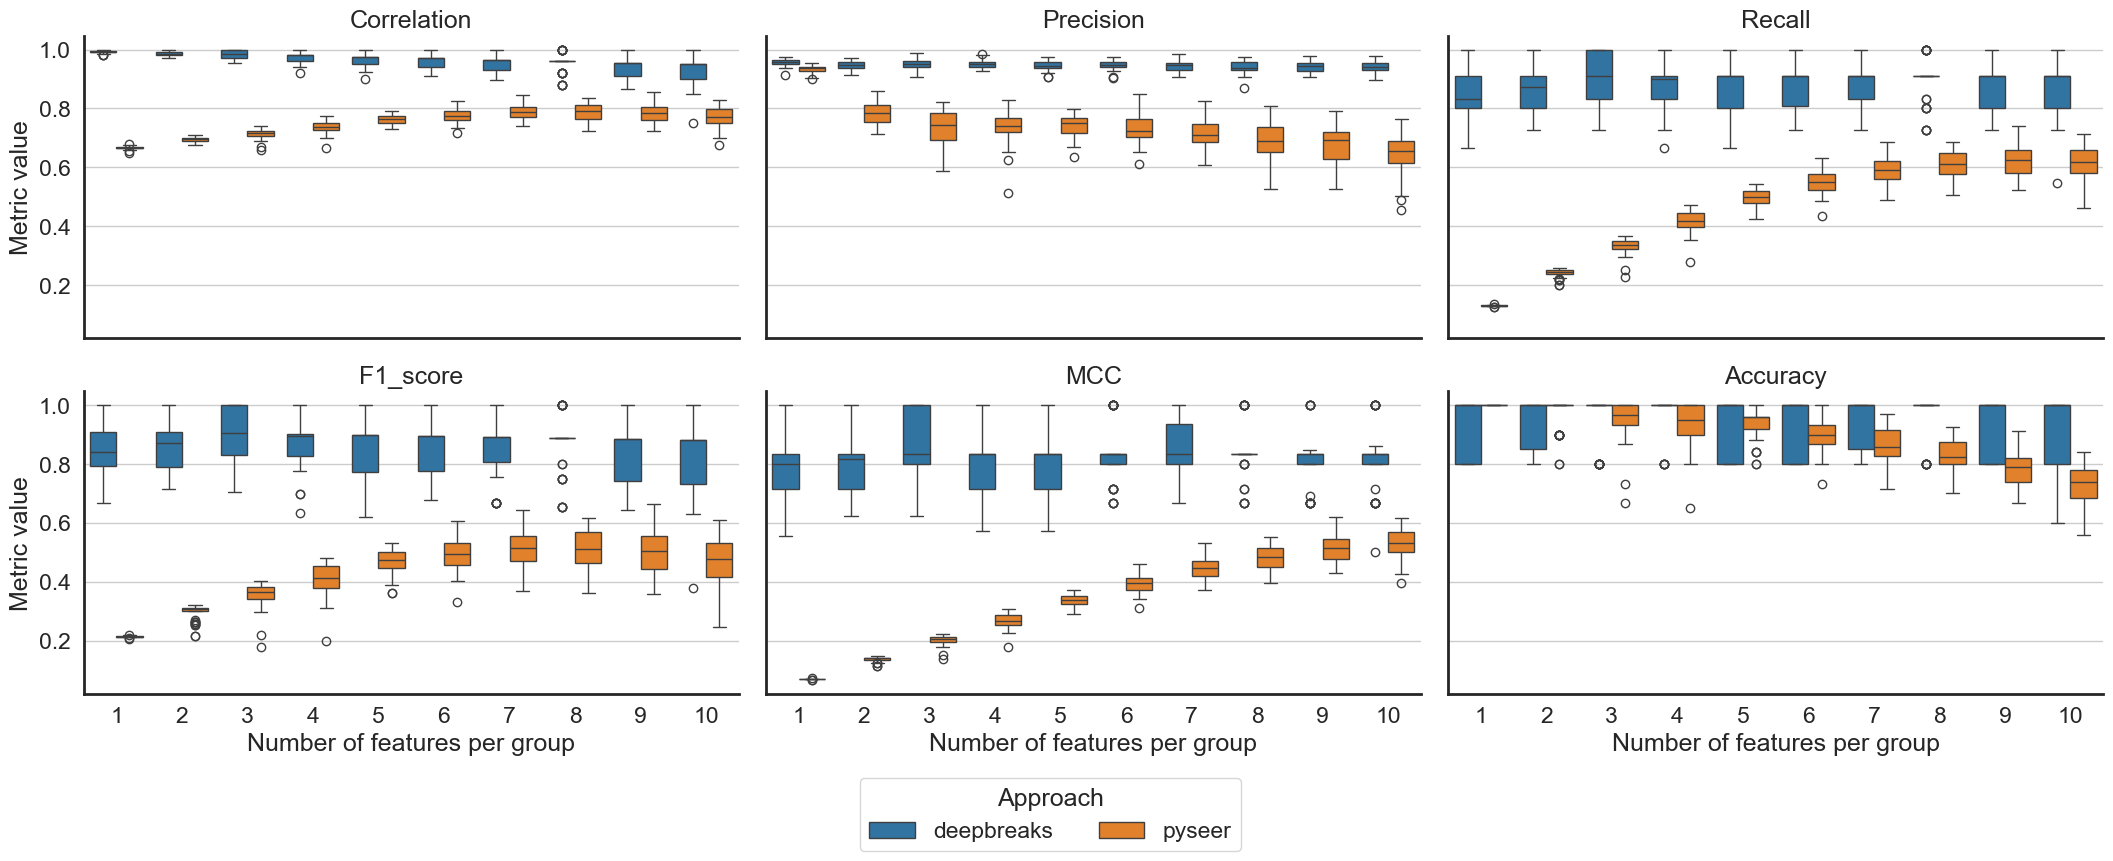

In [ ]:
# Set figure size
plt.figure(figsize=(7.2, 4))
sns.set(style="white", font_scale=1.5)

# Create FacetGrid with adjusted size parameters
g = sns.FacetGrid(df_melted, col='metric', hue='approach', col_wrap=3, height=4, 
                  aspect=7.2/(4))  # Aspect ratio to match overall figure size

# Use catplot instead of directly mapping boxplot to properly handle categorical data
# The key fix is to include 'x' parameter to position boxplots side-by-side
for ax, (name, data) in zip(g.axes.flatten(), df_melted.groupby('metric')):
    sns.boxplot(x='features_per_group', y='value', hue='approach', data=data, palette='tab10',
                ax=ax, dodge=True)  # dodge=True ensures side-by-side placement
    ax.get_legend().remove()  # Remove individual legends

# Add single legend at bottom
handles, labels = g.axes[0].get_legend_handles_labels()
g.fig.legend(handles, labels, loc='lower center', ncol=len(labels), 
             bbox_to_anchor=(0.5, -0.1), title='Approach')

# Set labels and titles
g.set_axis_labels('Number of features per group', 'Metric value')
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.yaxis.grid(True)
    for spine in ax.spines.values():
        spine.set_linewidth(2) 

# Adjust layout to make room for the legend at bottom
g.fig.subplots_adjust(top=0.9, bottom=0.2)

plt.tight_layout()
plt.savefig('simulation_benchmark.png', dpi=300, bbox_inches='tight')